# Modello per l'Identificazione della Lingua di Testi per un Museo </p> Caso d'Uso Aziendale: MuseumLangID

## Introduzione all'Azienda
MuseumLangID è un'iniziativa di un museo internazionale che ospita una vasta collezione di opere d'arte e manufatti. Le descrizioni degli oggetti sono spesso scritte in diverse lingue, e il personale del museo ha bisogno di uno strumento automatizzato per identificare rapidamente la lingua di questi testi.

## Problema
La gestione delle informazioni multilingue è una sfida significativa per il museo. Attualmente, la lingua di ogni descrizione deve essere identificata manualmente, il che richiede tempo e può portare a errori. Con l'espansione delle collezioni, il numero di testi da analizzare aumenta, rendendo necessario un approccio automatizzato e scalabile.

## Obiettivo del Progetto
L'obiettivo è sviluppare un modello di machine learning basato su tecniche di Natural Language Processing (NLP) per identificare la lingua di testi forniti dal museo. Questo modello dovrà:
1. Riconoscere automaticamente la lingua di un testo.
2. Supportare almeno 3 lingue principali.
3. Essere facile da integrare con il sistema esistente del museo.

## Benefici Attesi
- Automazione: Eliminare la necessità di identificazione manuale delle lingue.
- Efficienza: Processare rapidamente grandi volumi di testi.
- Accuratezza: Ridurre gli errori umani nell'identificazione delle lingue.

## Specifiche del Progetto
### Dataset
Il dataset è disponibile a questo link: https://raw.githubusercontent.com/Profession-AI/progetti-ml/refs/heads/main/Modello%20per%20l'identificazione%20della%20lingua%20dei%20testi%20di%20un%20museo/museo_descrizioni.csv. Contiene varie descrizioni in più lingue, con una colonna che rappresenta il codice della lingua, che è il target da prevedere.

### Tecnologie
- Linguaggio di programmazione: Python
- Librerie richieste:
    - scikit-learn
    - nltk
    - numpy
    - pandas

### Funzionalità Chiave
1. Preprocessing dei Dati:
    - Pulizia del testo (rimozione di caratteri speciali, normalizzazione).
    - Tokenizzazione e rappresentazione dei testi in un formato numerico (ad esempio, Bag of Words o TF-IDF).
2. Sviluppo del Modello:
    - Creazione di un modello di classificazione delle lingue basato su algoritmi di machine learning (ad esempio, Naive Bayes, Support Vector Machine o Random Forest).
    - Addestramento e validazione del modello sul dataset fornito.
3. Valutazione:
    - Utilizzare metriche come accuratezza, precisione, richiamo e F1-score per valutare le prestazioni del modello.

## Consegna
Dovrai consegnare un notebook che riporta la creazione del modello, i vari test per validare le sue performance e anche un commento a tali risultati.

## Import delle Librerie e hyperparametri

In [19]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import string
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [20]:
RANDOM_SEED = 42
TEST_SPLIT_SIZE = 0.3

# TF-IDF Hyperparameters
TFIDF_NGRAM_RANGE = (1, 2)  # Considera unigrammi e bigrammi
TFIDF_MIN_DF = 1  # Ignora parole che appaiono in meno del 20% dei documenti
TFIDF_MAX_DF = 1.0  # Ignora parole che appaiono in più dell'80% dei documenti (stop words)

# Models Hyperparameters
EPOCHS = 150

## 1. Dataset

In [21]:
dataset = pd.read_csv(
    'https://raw.githubusercontent.com/Profession-AI/progetti-ml/refs/heads/main/Modello%20per%20l%27identificazione%20della%20lingua%20dei%20testi%20di%20un%20museo/museo_descrizioni.csv')

dataset_testo = dataset.iloc[:, 0]  # Testo
dataset_lingua = dataset.iloc[:, -1]  # Codice Lingua (target)

# 3 righe per ogni classe
dataset.groupby(dataset.columns[-1]).head(3)

,Testo,Codice Lingua
0,Statua in marmo di un imperatore romano del II...,it
1,Anfora greca con decorazioni a figure nere,it
2,Dipinto rinascimentale raffigurante la Madonna...,it
98,Marble statue of a Roman emperor from the 2nd ...,en
99,Greek amphora with black-figure decorations,en
100,Renaissance painting depicting the Madonna and...,en
196,Marmorstatue eines römischen Kaisers aus dem 2...,de
197,Griechische Amphore mit schwarzfigurigen Verzi...,de
198,Renaissance-Gemälde der Madonna mit Kind,de


### 1.1 Analisi Esplorativa del Dataset

In [22]:
print(f"  Righe    : {dataset.shape[0]}")
print(f"  Colonne  : {dataset.shape[1]}")
print(f"  Features  : {dataset.columns.tolist()}")
print(f"  Lingue presenti: {dataset_lingua.nunique()}")
for lang, count in dataset_lingua.value_counts().items():
    print(f"    - {lang}: {count} campioni ({(count / dataset.shape[0]) * 100:.2f}%)")

  Righe    : 294
  Colonne  : 2
  Features  : ['Testo', 'Codice Lingua']
  Lingue presenti: 3
    - it: 98 campioni (33.33%)
    - en: 98 campioni (33.33%)
    - de: 98 campioni (33.33%)


- Il dataset è **perfettamente bilanciato**: ogni lingua ha lo stesso numero di campioni, quindi non è necessario applicare tecniche di oversampling/undersampling.
- **Nessun valore mancante**: il dataset è pronto per il preprocessing senza dover gestire missing values.

## 2. Data Preprocessing

La funzione di preprocessing `data_cleaner` si occupa di pulire e normalizzare i testi prima della vettorizzazione.

### Scelte implementative

**Nessuna lemmatizzazione** —> La scelta di non lemmatizzare è motivata da due ragioni:

1. **Dipendenza circolare**: la lemmatizzazione richiede di conoscere la lingua del testo a priori per scegliere il modello corretto (es. spaCy `it_core_news_sm` per l'italiano). Durante l'inferenza la lingua è proprio l'informazione che vogliamo predire e quindi non é possibile applicare la lemmatizzazione a test time.

2. **La morfologia è informativa per la language ID**: parole come `"paintings"` (suffisso `-ings` tipicamente inglese), `"correndo"` (gerundio italiano in `-endo`) o `"gespielt"` (participio tedesco con prefisso `ge-`) sono informazioni discriminative preziose. Lemmatizzarle significherebbe rimuovere queste caratteristiche distintive, rendendo il task più difficile.

**Stopwords mantenute** —> Al contrario della maggior parte dei task NLP, qui le stopwords sono tra le feature più utili: articoli (`"the"`, `"il"`, `"der"`, `"le"`), preposizioni e congiunzioni possono essere altamente specifici di una lingua e quindi vanno preservati.

**Numeri rimossi** —> Irrilevanti per l'identificazione della lingua.

In [23]:
def data_cleaner(dataset_testo):
    """
    Funzione per il preprocessing dei testi: rimozione di punteggiatura, numeri e spazi extra.
    I testi vengono convertiti in minuscolo per uniformità.

    :param dataset_testo: Dataframe di testi
    :return: lista di testi puliti
    """
    dataset_to_return = []
    for sentence in dataset_testo:
        sentence = sentence.lower()
        for c in string.punctuation:
            sentence = sentence.replace(c, " ")
        sentence = re.sub(r'\d+', '', sentence) # rimozione numeri
        sentence = re.sub(r'\s+', ' ', sentence).strip() # rimozione spazi extra
        dataset_to_return.append(sentence)
    return dataset_to_return

# Pulizia del dataset
dataset_cleaned = data_cleaner(dataset_testo)

### 2.1 Split del Dataset e Feature Extraction

Dopo la pulizia base, il dataset viene diviso in training set (100% - `TEST_SPLIT_SIZE`) e test set (`TEST_SPLIT_SIZE`), mantenendo la stessa distribuzione di classi (stratificazione). Successivamente i testi vengono convertiti in vettori numerici tramite **TF-IDF** con le seguenti scelte:

- **`ngram_range=(1, 2)`**: oltre ai singoli token (unigrammi), vengono considerati anche i bigrammi cioè sequenze di due parole consecutive come `"de la"`, `"of the"`, `"in der"`.

- **Nessun filtro su `min_df`/`max_df`**: il vocabolario ottenuto senza filtri ha esattamente 1568 feature, una dimensione gestibile da tutti e tre i modelli senza rischio di consumo eccessivo di memoria o tempi di training elevati.

In [24]:
# Split del dataset
X_train, X_test, y_train, y_test = train_test_split(dataset_cleaned, dataset_lingua, test_size=TEST_SPLIT_SIZE, random_state=RANDOM_SEED, stratify=dataset_lingua)

# Feature extraction con TF-IDF
vectorizer = TfidfVectorizer(ngram_range=TFIDF_NGRAM_RANGE, min_df=TFIDF_MIN_DF, max_df=TFIDF_MAX_DF)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"  Training set : {len(X_train)} campioni ({(1 - TEST_SPLIT_SIZE) * 100:.0f}%)")
print(f"  Test set     : {len(X_test)} campioni ({TEST_SPLIT_SIZE * 100:.0f}%)")
print()
print("  Distribuzione nel Training set:")
for lang, count in y_train.value_counts().items():
    print(f"    - {lang}: {count} campioni ({(count / len(y_train)) * 100:.2f}%)")
print()
print("  Distribuzione nel Test set:")
for lang, count in y_test.value_counts().items():
    print(f"    - {lang}: {count} campioni ({(count / len(y_test)) * 100:.2f}%)")
print()
print("  Forma della matrice TF-IDF del training set: ", X_train_tfidf.shape)
print("  Forma della matrice TF-IDF del test set: ", X_test_tfidf.shape)

  Training set : 205 campioni (70%)
  Test set     : 89 campioni (30%)

  Distribuzione nel Training set:
    - de: 69 campioni (33.66%)
    - it: 68 campioni (33.17%)
    - en: 68 campioni (33.17%)

  Distribuzione nel Test set:
    - it: 30 campioni (33.71%)
    - en: 30 campioni (33.71%)
    - de: 29 campioni (32.58%)

  Forma della matrice TF-IDF del training set:  (205, 1568)
  Forma della matrice TF-IDF del test set:  (89, 1568)


## 3. Sviluppo e Addestramento dei Modelli

### Modello 1: Naive Bayes Multinomiale

In [25]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# Predizioni
y_pred_nb = nb_model.predict(X_test_tfidf)

# Accuratezza
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuratezza: {accuracy_nb:.4f}")
print(f"\nReport di classificazione:\n{classification_report(y_test, y_pred_nb)}")

Accuratezza: 1.0000

Report di classificazione:
              precision    recall  f1-score   support

          de       1.00      1.00      1.00        29
          en       1.00      1.00      1.00        30
          it       1.00      1.00      1.00        30

    accuracy                           1.00        89
   macro avg       1.00      1.00      1.00        89
weighted avg       1.00      1.00      1.00        89



### Modello 2: Support Vector Machine (LinearSVC)

In [26]:
svm_model = LinearSVC(random_state=RANDOM_SEED, max_iter=EPOCHS)
svm_model.fit(X_train_tfidf, y_train)

# Predizioni
y_pred_svm = svm_model.predict(X_test_tfidf)

# Accuratezza
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuratezza: {accuracy_svm:.4f}")
print(f"\nReport di classificazione:\n{classification_report(y_test, y_pred_svm)}")

Accuratezza: 1.0000

Report di classificazione:
              precision    recall  f1-score   support

          de       1.00      1.00      1.00        29
          en       1.00      1.00      1.00        30
          it       1.00      1.00      1.00        30

    accuracy                           1.00        89
   macro avg       1.00      1.00      1.00        89
weighted avg       1.00      1.00      1.00        89



### Modello 3: Multy Layer Perceptron (MLP Classifier)

Questo **MLPClassifier** è una rete neurale feed-forward con due strati nascosti (256 → 128 neuroni). Viene usata la `Relu` come funzione di attivazione e `adam` come ottimizzatore. Il modello é stato allenato per `EPOCHS` iterazioni.

In [27]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    max_iter=EPOCHS,
    random_state=RANDOM_SEED)

mlp_model.fit(X_train_tfidf, y_train)

# Predizioni
y_pred_mlp = mlp_model.predict(X_test_tfidf)

# Accuratezza
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
print(f"Accuratezza: {accuracy_mlp:.4f}")
print(f"\nReport di classificazione:\n{classification_report(y_test, y_pred_mlp)}")

Accuratezza: 1.0000

Report di classificazione:
              precision    recall  f1-score   support

          de       1.00      1.00      1.00        29
          en       1.00      1.00      1.00        30
          it       1.00      1.00      1.00        30

    accuracy                           1.00        89
   macro avg       1.00      1.00      1.00        89
weighted avg       1.00      1.00      1.00        89



## 4. Valutazione e Confronto dei Modelli

In [28]:
models_map = {
    'Naive Bayes':     (nb_model, y_pred_nb),
    'Linear SVC': (svm_model, y_pred_svm),
    'MLP Classifier':  (mlp_model, y_pred_mlp)
}

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

In [29]:
results = []
for name, ( _ , y_pred) in models_map.items():
    results.append({
        'Modello':     name,
        'Accuracy':    accuracy_score(y_test, y_pred),
        'Precision':  precision_score(y_test, y_pred, average='weighted'),
        'Recall':    recall_score(y_test, y_pred, average='weighted'),
        'F1-Score':    f1_score(y_test, y_pred, average='weighted'),
    })

model_comparison_df = pd.DataFrame(results)

print("TABELLA COMPARATIVA DELLE METRICHE:\n")
print(model_comparison_df.to_string(index=False))

TABELLA COMPARATIVA DELLE METRICHE:

       Modello  Accuracy  Precision  Recall  F1-Score
   Naive Bayes       1.0        1.0     1.0       1.0
    Linear SVC       1.0        1.0     1.0       1.0
MLP Classifier       1.0        1.0     1.0       1.0


### 4.1 Visualizzazione Grafica dei Risultati

Per ogni metrica (accuratezza, precisione, richiamo, F1-score) viene creato un grafico a barre che confronta le prestazioni dei tre modelli.

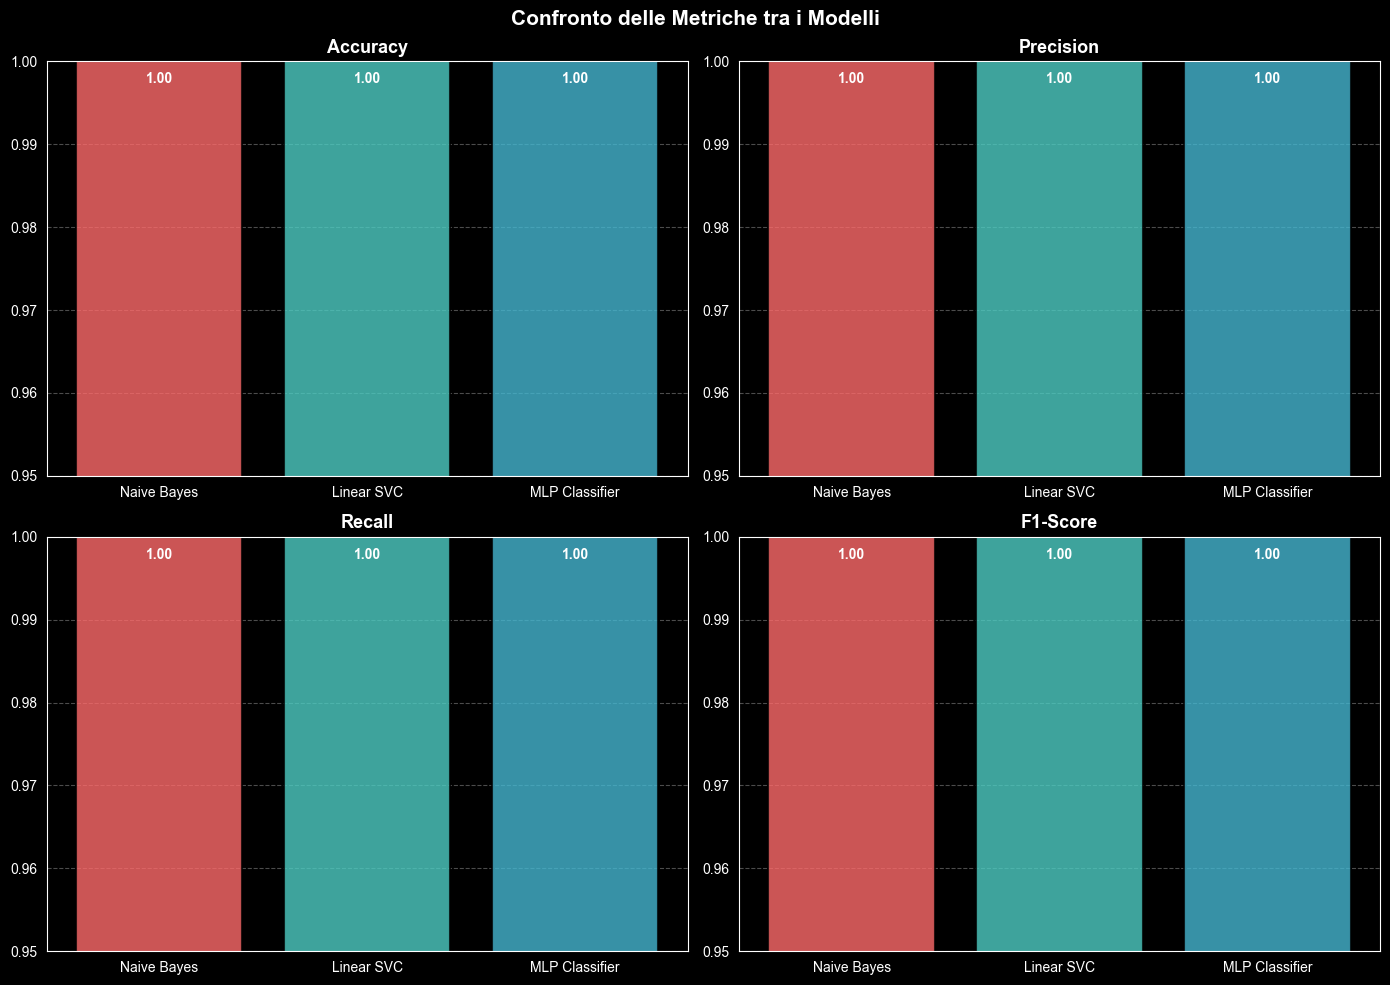

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, metrica in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = model_comparison_df[metrica].tolist()
    bars = ax.bar(model_comparison_df['Modello'], values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_title(f'{metrica}', fontsize=13, fontweight='bold')
    ax.set_ylim([max(0.0, min(values) - 0.05), 1])
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.grid(axis='x', alpha=0)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2.,  height - 0.003,
                f'{height:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Confronto delle Metriche tra i Modelli', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('images/modelli_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

### 4.2 Matrici di Confusione

Viene creata una matrice di confusione per ogni modello, visualizzata con una heatmap. Le matrici mostrano il numero di predizioni corrette e errate per ogni lingua. Le etichette degli assi rappresentano le lingue vere (asse y) e le lingue predette (asse x).

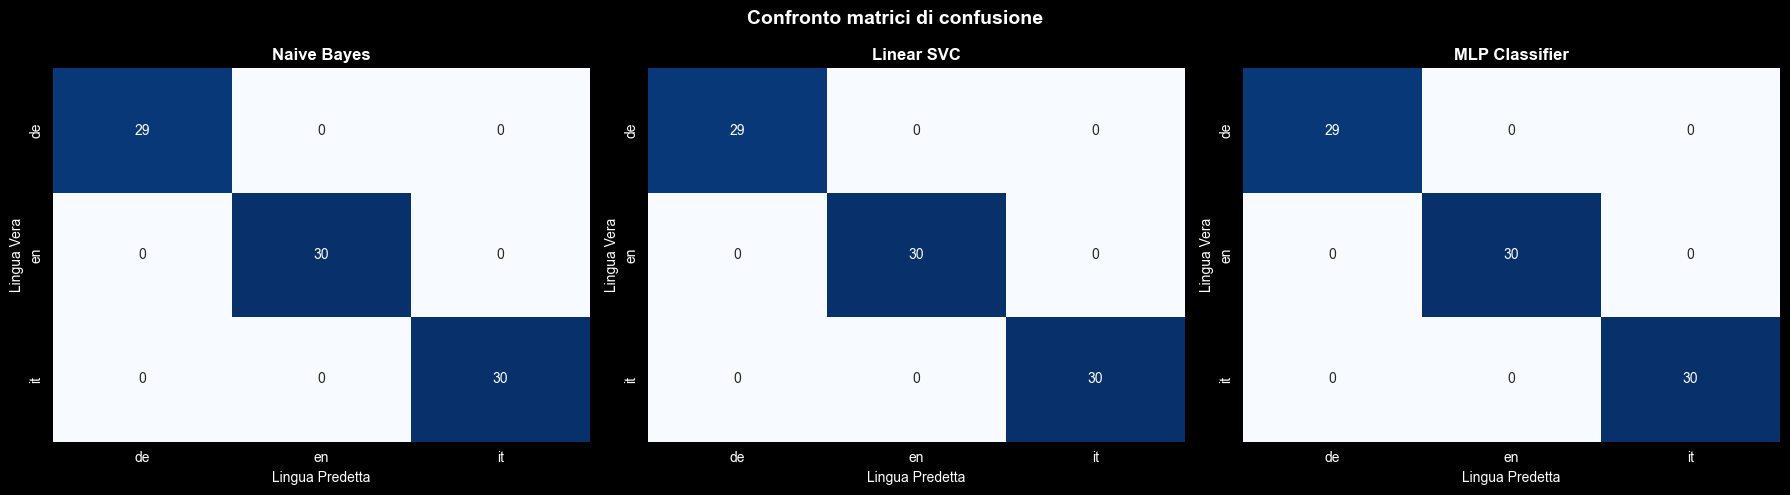

In [31]:
lang_labels = sorted(dataset_lingua.unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (name, (model, y_pred)) in enumerate(models_map.items()):
    ax = axes[idx % 3]
    cm = confusion_matrix(y_test, y_pred, labels=lang_labels)
    sns.heatmap(cm, annot=True, cmap='Blues', ax=ax, xticklabels=lang_labels, yticklabels=lang_labels, cbar=False)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Lingua Predetta', fontsize=10)
    ax.set_ylabel('Lingua Vera', fontsize=10)

plt.suptitle('Confronto matrici di confusione', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

## Conclusioni

### Analisi dei Risultati

Tutti e tre i modelli raggiungono prestazioni molto elevate, ottenendo il 100% di accuratezza, precisione, richiamo e F1-score. Questo risultato indica che il task di language identification su questo dataset è semplice, con tutte le lingue facilmente separabili nello spazio TF-IDF.

---

### Scelta del Modello per la Produzione

Dati i risultati equivalenti dei modelli, la scelta definitiva ricade su **Naive Bayes Multinomiale** oppure **Linear SVC** per i seguenti motivi

- Training e inferenza più veloci di una rete neurale
- Nessun hyperparameter critico (learning rate, architettura) da ottimizzare

---

### Limiti e Possibili Miglioramenti

Una secondo approccio potrebbe essere quello di utilizzare un **character n-grams** invece di word n-grams. Questo approccio potrebbe essere più efficace in scenari più complessi con più lingue o con errori di battitura, poiché cattura pattern a livello di carattere, rendendo il modello più robusto a variazioni linguistiche e errori di digitazione.